# PFN trained on an RBF Gaussian-process prior

In [1]:
import math

import matplotlib.pyplot as plt
import torch
import torch.nn as nn


from datasets.GP_RBF import sample_gp_rbf_data
from model import PFNRegressor, RiemannDistribution, eval_step, train_step

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

GP_LENGTHSCALE = 0.1
GP_NOISE = 0.0 
MAX_NUM_POINTS = 20

NUM_BUCKETS = 1000
DATA_SETS_FOR_BUCKETS = 500_000
torch.cuda.empty_cache()

device: cuda


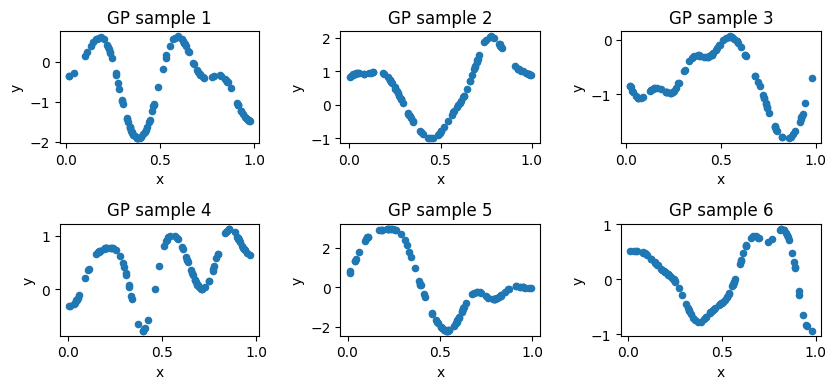

In [2]:
# Visual sanity check: samples from the exact GP prior.
x_batch, y_batch = sample_gp_rbf_data(
    num_datasets=6,
    num_points_in_each_dataset=100,
    lengthscale=GP_LENGTHSCALE,
    noise=GP_NOISE,
    device=DEVICE,
)

fig, axes = plt.subplots(2, 3, figsize=(8.6,4))
for i, ax in enumerate(axes.flatten()):
    ax.scatter(x_batch[i, :, 0].cpu(), y_batch[i, :, 0].cpu(), s=20)
    ax.set_title(f"GP sample {i + 1}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
plt.tight_layout()
plt.show()


In [3]:
# Fit the bar-distribution buckets from the same GP prior used for training.
_, prior_y = sample_gp_rbf_data(
    num_datasets=DATA_SETS_FOR_BUCKETS,
    num_points_in_each_dataset=MAX_NUM_POINTS,
    lengthscale=GP_LENGTHSCALE,
    noise=GP_NOISE,
    device=DEVICE,
)

dist = RiemannDistribution.fit_equal_mass_buckets(
    y_samples=prior_y,
    num_buckets=NUM_BUCKETS,
).to(DEVICE)

print("bucket range:", float(dist.boundaries[0]), float(dist.boundaries[-1]))
print("num buckets:", dist.num_buckets)


bucket range: -5.242233753204346 4.979201316833496
num buckets: 1000


In [ ]:
model = PFNRegressor(
    x_dim=1,
    y_dim=1,
    emb_size=512,
    n_heads=8,
    ff_hidden=1024,
    n_layers=16,
    num_buckets=NUM_BUCKETS,
    dropout=0.0,
    use_x_norm=False,      # important: preserve the GP lengthscale in [0, 1]
    decoder_hidden=1024,
).to(DEVICE)

total, trainable = model.print_parameter_count()
print(f"Total parameters: {total * 1e-6:.2f} M")
print(f"Trainable parameters: {trainable * 1e-6:.2f} M")

# Access backbone and decoder separately.
print(model.backbone)
print(model.decoder)


Total parameters: 35.21 M
Trainable parameters: 35.21 M
PFNBackbone(
  (x_encoder): Linear(in_features=1, out_features=512, bias=True)
  (y_encoder): Linear(in_features=2, out_features=512, bias=True)
  (blocks): ModuleList(
    (0-15): 16 x TransformerBlock(
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
      )
      (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (norm3): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=512, out_features=1024, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=1024, out_features=512, bias=True)
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
  )
)
BucketDecoder(
  (0): Linear(in_features=512, out_features=1024, bias=True)
  (1): GELU(approximate='none')
  (2): Linear(in_feat

In [ ]:
def PFN_train_gp(
    model,
    dist,
    optimizer,
    batch_size=256,
    epochs=20,
    steps_per_epoch=1000,
    max_num_points=MAX_NUM_POINTS,
    lengthscale=GP_LENGTHSCALE,
    noise=GP_NOISE,
    device=DEVICE,
):
    total_steps = epochs * steps_per_epoch
    warmup_steps = (epochs // 4) * steps_per_epoch

    def lr_lambda(step):
        if step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    total_datasets = batch_size * epochs * steps_per_epoch
    print(f"total datasets: {total_datasets:,}")
    print(f"num points per task: {max_num_points}")

    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        for _ in range(steps_per_epoch):
            x_batch, y_batch = sample_gp_rbf_data(
                num_datasets=batch_size,
                num_points_in_each_dataset=max_num_points,
                lengthscale=lengthscale,
                noise=noise,
                device=device,
            )
            loss = train_step(
                model=model,
                optimizer=optimizer,
                dist=dist,
                x_all=x_batch,
                y_all=y_batch,
                max_grad_norm=1.0
            )
            scheduler.step()
            epoch_loss += loss

        epoch_loss /= steps_per_epoch
        print(f"epoch={epoch:02d} loss={epoch_loss:.4f} lr={optimizer.param_groups[0]['lr']:.2e}")


In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0,
)

# PFN_train_gp(
#     model=model,
#     dist=dist,
#     optimizer=optimizer,
#     batch_size=200,
#     epochs=50,
#     steps_per_epoch=1000,
#     max_num_points=20,
#     lengthscale=GP_LENGTHSCALE,
#     noise=GP_NOISE,
#     device=DEVICE,
# )

import os 

model_path = "pfn_model_GP.pt"
if os.path.exists(model_path):
    print(f"Loading model from {model_path}...")
    checkpoint = torch.load(model_path, map_location=DEVICE)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    print("Model loaded successfully.")
else:
    print("No saved model found. Training from scratch.")


Loading model from pfn_model_GP.pt...
Model loaded successfully.


In [ ]:
@torch.no_grad()
def PFN_eval_gp(
    model,
    dist,
    num_datasets=1000,
    num_points=MAX_NUM_POINTS,
    lengthscale=GP_LENGTHSCALE,
    noise=GP_NOISE,
    device=DEVICE,
):
    x_eval, y_eval = sample_gp_rbf_data(
        num_datasets=num_datasets,
        num_points_in_each_dataset=num_points,
        lengthscale=lengthscale,
        noise=noise,
        device=device,
    )

    out = eval_step(model=model, dist=dist, x_eval=x_eval, y_eval=y_eval)
    print("Evaluation")
    print("n_points:", num_points)
    print("n_context:", out["n_context"])
    print("mean NLL:", f"{out['loss']:.4f}")
    print("MAE to sampled y:", f"{out['mae']:.4f}")
    return out

result = PFN_eval_gp(model, dist)


Evaluation
n_points: 20
n_context: 13
mean NLL: -1.9652
MAE to sampled y: 0.0853


In [ ]:
def rbf_kernel(x1, x2, lengthscale=GP_LENGTHSCALE):
    lengthscale = torch.as_tensor(lengthscale, device=x1.device, dtype=x1.dtype)
    diff = x1[:, None, :] - x2[None, :, :]
    return torch.exp(-0.5 * diff.square().sum(dim=-1) / lengthscale**2)


def cholesky_with_adaptive_jitter_2d(K, initial_jitter=1e-8, max_tries=10):
    """Cholesky for nearly singular GP covariance matrices.

    Returns both the factor and the jitter that was actually added, so the
    predictive variance can include the same stabilizer used for inference.
    """
    eye = torch.eye(K.shape[0], device=K.device, dtype=K.dtype)
    jitter = initial_jitter

    for _ in range(max_tries):
        try:
            return torch.linalg.cholesky(K + jitter * eye), jitter
        except torch.linalg.LinAlgError:
            jitter *= 10.0

    return torch.linalg.cholesky(K + jitter * eye), jitter


@torch.no_grad()
def exact_gp_posterior(
    x_ctx,
    y_ctx,
    x_test,
    lengthscale=GP_LENGTHSCALE,
    noise=GP_NOISE,
    gp_device="cpu",
    gp_dtype=torch.float64,
):
    """Numerically stable exact GP posterior.

    The exact GP baseline is evaluated in float64, by default on CPU, because
    zero-noise RBF kernels with many nearby points are very ill-conditioned in
    float32 and can create artificial NLL spikes.
    """
    out_device = x_test.device
    x_ctx_gp = x_ctx.detach().to(device=gp_device, dtype=gp_dtype)
    y_ctx_gp = y_ctx.detach().to(device=gp_device, dtype=gp_dtype)
    x_test_gp = x_test.detach().to(device=gp_device, dtype=gp_dtype)

    K = rbf_kernel(x_ctx_gp, x_ctx_gp, lengthscale)
    if noise > 0:
        K = K + noise * torch.eye(x_ctx_gp.shape[0], device=gp_device, dtype=gp_dtype)
    Ks = rbf_kernel(x_ctx_gp, x_test_gp, lengthscale)
    Kss_diag = torch.ones(x_test_gp.shape[0], device=gp_device, dtype=gp_dtype)

    L, used_jitter = cholesky_with_adaptive_jitter_2d(K)
    alpha = torch.cholesky_solve(y_ctx_gp, L)
    mean = Ks.transpose(0, 1) @ alpha
    v = torch.cholesky_solve(Ks, L)
    var = (Kss_diag - (Ks * v).sum(dim=0)).clamp_min(used_jitter)
    return mean.squeeze(-1).to(out_device), var.to(out_device), used_jitter


@torch.no_grad()
def plot_pfn_vs_exact_gp(
    model,
    dist,
    n_context=5,
    total_points=MAX_NUM_POINTS,
    grid_size=400,
    lengthscale=GP_LENGTHSCALE,
    noise=GP_NOISE,
    device=DEVICE,
):
    model.eval()
    x_all, y_all = sample_gp_rbf_data(
        num_datasets=1,
        num_points_in_each_dataset=total_points,
        lengthscale=lengthscale,
        noise=noise,
        device=device,
    )
    x_all = x_all[0]
    y_all = y_all[0]

    perm = torch.randperm(total_points, device=device)
    ctx_idx = perm[:n_context]
    qry_idx = perm[n_context:]
    x_ctx = x_all[ctx_idx]
    y_ctx = y_all[ctx_idx]
    x_qry = x_all[qry_idx]
    y_qry = y_all[qry_idx]

    order = torch.argsort(x_ctx[:, 0])
    x_ctx = x_ctx[order]
    y_ctx = y_ctx[order]

    x_grid = torch.linspace(0, 1, grid_size, device=device, dtype=x_ctx.dtype).view(-1, 1)
    logits = model(x_ctx.unsqueeze(0), y_ctx.unsqueeze(0), x_grid.unsqueeze(0))
    pfn_mean = dist.mean(logits)[0]
    pfn_lower = dist.quantile(logits, 0.025)[0]
    pfn_upper = dist.quantile(logits, 0.975)[0]

    gp_mean, gp_var, _ = exact_gp_posterior(x_ctx, y_ctx, x_grid, lengthscale, noise)
    gp_std = gp_var.sqrt()

    mean_mae = (pfn_mean - gp_mean).abs().mean().item()
    x_np = x_grid[:, 0].cpu().numpy()

    plt.figure(figsize=(8, 5))
    plt.scatter(x_ctx[:, 0].cpu(), y_ctx[:, 0].cpu(), s=70, color="black", zorder=5, label=f"context (n={n_context})")
    order = torch.argsort(x_qry[:, 0])

    plt.plot(
        x_qry[order, 0].cpu(),
        y_qry[order, 0].cpu(),
        color="gray",
        alpha=0.6,
        linewidth=2,
        label="true function",
    )
    
    plt.plot(x_np, pfn_mean.cpu().numpy(), linewidth=2, label="PFN mean")
    plt.fill_between(x_np, pfn_lower.cpu().numpy(), pfn_upper.cpu().numpy(), alpha=0.2, label="PFN 95% interval")
    plt.plot(x_np, gp_mean.cpu().numpy(), "--", linewidth=2, label="exact GP mean")
    plt.fill_between(
        x_np,
        (gp_mean - 1.96 * gp_std).cpu().numpy(),
        (gp_mean + 1.96 * gp_std).cpu().numpy(),
        alpha=0.2,
        label="exact GP 95% interval",
    )
    plt.xlim(0, 1)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("PFN-vs-GP mean MAE:", f"{mean_mae:.4f}")
    print("feature shape:", model.encode(x_ctx.unsqueeze(0), y_ctx.unsqueeze(0), x_grid.unsqueeze(0)).shape)
    print("logit shape:", logits.shape)
    return mean_mae


In [ ]:
plot_pfn_vs_exact_gp(model, dist, n_context=2, total_points=500)

In [ ]:
# MODEL_PATH = "pfn_model_GP.pt"

# torch.save({
#     "model_state_dict": model.state_dict(),
#     "optimizer_state_dict": optimizer.state_dict(),
#     "config": {
#         "x_dim": 1,
#         "emb_size": 512,
#         "n_layers": 8,
#         "n_heads": 8,
#         "ff_hidden": 1024,
#         "decoder_hidden": 1024,
#         "num_buckets": NUM_BUCKETS,
#         "dropout": 0.0,
#         "use_x_norm": False,
#         "gp_lengthscale": GP_LENGTHSCALE,
#         "gp_noise": GP_NOISE,
#         "max_num_points": MAX_NUM_POINTS,
#     },
# }, MODEL_PATH)

# print(f"Model saved to {MODEL_PATH}")


## Fixed-lengthscale dataset-budget comparison

Train separate PFNs on 500K, 1M, 2M, and 4M fixed-lengthscale GP datasets, then compare PFN NLL against the exact GP posterior NLL on the same held-out splits.


In [ ]:
# Load PFNs trained on different numbers of fixed-lengthscale GP datasets.
# This cell does not retrain. If a checkpoint is missing, it raises an error so
# we do not accidentally start an expensive training run.

from pathlib import Path

FIXED_LENGTHSCALE_DATASET_BUDGETS = [500_000, 1_000_000, 2_000_000, 4_000_000]
FIXED_COMPARE_BATCH_SIZE = 100
FIXED_COMPARE_STEPS_PER_EPOCH = 1_000
FIXED_CHECKPOINT_DIR = Path("checkpoints/gp_fixed_lengthscale")


def build_gp_pfn(num_buckets=NUM_BUCKETS, device=DEVICE):
    return PFNRegressor(
        x_dim=1,
        y_dim=1,
        emb_size=512,
        n_heads=8,
        ff_hidden=1024,
        n_layers=16,
        num_buckets=num_buckets,
        dropout=0.0,
        use_x_norm=False,
        decoder_hidden=1024,
    ).to(device)


def budget_to_epochs(total_datasets, batch_size=FIXED_COMPARE_BATCH_SIZE, steps_per_epoch=FIXED_COMPARE_STEPS_PER_EPOCH):
    datasets_per_epoch = batch_size * steps_per_epoch
    if total_datasets % datasets_per_epoch != 0:
        raise ValueError(
            f"Budget {total_datasets:,} is not divisible by "
            f"batch_size * steps_per_epoch = {datasets_per_epoch:,}."
        )
    return total_datasets // datasets_per_epoch


def fixed_checkpoint_candidates(budget):
    """Prefer the organized checkpoint dir, but support older root-level files."""
    return [
        FIXED_CHECKPOINT_DIR / f"pfn_gp_fixed_l{GP_LENGTHSCALE:g}_{budget // 1000}K.pt",
        Path(f"gp_fixed_l{GP_LENGTHSCALE:g}_{budget // 1000}K.pt"),
    ]


def first_existing_path(paths):
    for path in paths:
        if path.exists():
            return path
    return None


@torch.no_grad()
def gp_posterior_nll_from_split(x_ctx, y_ctx, x_query, y_query, lengthscale=GP_LENGTHSCALE, noise=GP_NOISE):
    """Exact GP posterior predictive NLL for the same context/query split used by the PFN."""
    per_dataset_nll = []
    obs_noise = noise + 1e-6

    for b in range(x_ctx.shape[0]):
        mean, var, used_jitter = exact_gp_posterior(
            x_ctx[b],
            y_ctx[b],
            x_query[b],
            lengthscale=lengthscale,
            noise=noise,
        )
        pred_var = (var + obs_noise).clamp_min(float(used_jitter))
        y = y_query[b, :, 0].to(mean.device, mean.dtype)
        nll = 0.5 * (math.log(2.0 * math.pi) + torch.log(pred_var) + (y - mean).square() / pred_var)
        per_dataset_nll.append(nll.mean())

    per_dataset_nll = torch.stack(per_dataset_nll)
    return {
        "loss": float(per_dataset_nll.mean().item()),
        "loss_per_dataset": per_dataset_nll,
    }


fixed_lengthscale_models = {}
missing_checkpoints = []

for budget in FIXED_LENGTHSCALE_DATASET_BUDGETS:
    checkpoint_path = first_existing_path(fixed_checkpoint_candidates(budget))
    print(f"\n=== Fixed lengthscale budget: {budget:,} datasets ===")

    if checkpoint_path is None:
        expected_paths = fixed_checkpoint_candidates(budget)
        missing_checkpoints.append(" or ".join(str(path) for path in expected_paths))
        print("Missing checkpoint. Looked for:", expected_paths)
        continue

    compare_model = build_gp_pfn().to(DEVICE)
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    compare_model.load_state_dict(checkpoint["model_state_dict"])
    compare_model.eval()
    fixed_lengthscale_models[budget] = compare_model
    print(f"Loaded checkpoint: {checkpoint_path}")

if missing_checkpoints:
    raise FileNotFoundError(
        "Missing fixed-lengthscale checkpoint(s). Train them first, or update FIXED_CHECKPOINT_DIR/path names:\n"
        + "\n".join(missing_checkpoints)
    )

print("Loaded fixed-lengthscale models:", [f"{b:,}" for b in fixed_lengthscale_models])



=== Fixed lengthscale budget: 500,000 datasets ===
Loaded checkpoint: gp_fixed_l0.1_500K.pt

=== Fixed lengthscale budget: 1,000,000 datasets ===
Loaded checkpoint: gp_fixed_l0.1_1000K.pt

=== Fixed lengthscale budget: 2,000,000 datasets ===
Loaded checkpoint: gp_fixed_l0.1_2000K.pt

=== Fixed lengthscale budget: 4,000,000 datasets ===
Loaded checkpoint: gp_fixed_l0.1_4000K.pt
Loaded fixed-lengthscale models: ['500,000', '1,000,000', '2,000,000', '4,000,000']


In [ ]:
# Replicate the paper-style figure: NLL versus number of revealed/context data points.
# Each PFN curve is averaged over many fresh GP tasks. The GP curve is the exact
# posterior predictive NLL using the known fixed lengthscale.
#
# Important: n_context goes up to 2000, so evaluation is streamed in small
# batches to avoid allocating a giant [num_datasets, 2001, 2001] GP covariance.

import gc

from model.sampling import random_split_context_query

NLL_CURVE_CONTEXT_VALUES = sorted(set(torch.linspace(1, 50, steps=100).round().long().tolist()))
NLL_CURVE_EVAL_DATASETS = 100
NLL_CURVE_EVAL_BATCH_SIZE = 100
NLL_CURVE_TOTAL_POINTS = max(MAX_NUM_POINTS, max(NLL_CURVE_CONTEXT_VALUES) + 1)
# Use an explicit tiny observation noise for large-context evaluation.
# This keeps the sampled data and exact GP NLL on the same numerical model.
NLL_CURVE_GP_NOISE = 1e-6
SAVE_NLL_CURVE_FIGURE = "gp_fixed_lengthscale_nll_curve.png"


def clear_cuda_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def sample_gp_rbf_data_for_eval(
    num_datasets,
    num_points_in_each_dataset,
    lengthscale=GP_LENGTHSCALE,
    noise=NLL_CURVE_GP_NOISE,
    device=DEVICE,
    gp_device="cpu",
    gp_dtype=torch.float64,
):
    """Stable GP evaluation sampler.

    Large zero-noise RBF covariance matrices are ill-conditioned in float32.
    For the GP baseline figure we sample on CPU in float64 with an explicit
    small observation noise, then move tensors back to the model device.
    """
    B = num_datasets
    N = num_points_in_each_dataset
    x = torch.sort(torch.rand(B, N, 1, device=gp_device, dtype=gp_dtype), dim=1).values
    diff = x - x.transpose(1, 2)
    K = torch.exp(-0.5 * diff.square() / lengthscale**2)
    eye = torch.eye(N, device=gp_device, dtype=gp_dtype).expand(B, N, N)
    K = K + noise * eye

    try:
        from datasets.GP_RBF import _cholesky_with_adaptive_jitter
        L = _cholesky_with_adaptive_jitter(K, initial_jitter=1e-10)
    except ImportError:
        L = torch.linalg.cholesky(K + 1e-10 * eye)

    y = L @ torch.randn(B, N, 1, device=gp_device, dtype=gp_dtype)
    return x.to(device=device, dtype=torch.float32), y.to(device=device, dtype=torch.float32)


@torch.no_grad()
def evaluate_pfn_nll_on_split(model, dist, x_ctx, y_ctx, x_query, y_query):
    model.eval()
    logits = model(x_ctx, y_ctx, x_query)
    nll = dist.nll(logits, y_query.squeeze(-1))
    return float(nll.mean().item())


@torch.no_grad()
def evaluate_nll_curve_fixed_gp(
    models_by_budget,
    dist,
    n_context_values=NLL_CURVE_CONTEXT_VALUES,
    num_eval_datasets=NLL_CURVE_EVAL_DATASETS,
    eval_batch_size=NLL_CURVE_EVAL_BATCH_SIZE,
    total_points=NLL_CURVE_TOTAL_POINTS,
    lengthscale=GP_LENGTHSCALE,
    noise=NLL_CURVE_GP_NOISE,
    device=DEVICE,
):
    curve = {budget: [] for budget in models_by_budget}
    curve["Exact GP"] = []

    for n_context in n_context_values:
        if not (1 <= n_context < total_points):
            raise ValueError(f"n_context={n_context} must be in [1, {total_points - 1}].")

        running = {budget: 0.0 for budget in models_by_budget}
        running["Exact GP"] = 0.0
        seen = 0

        for start in range(0, num_eval_datasets, eval_batch_size):
            batch_size = min(eval_batch_size, num_eval_datasets - start)

            x_eval, y_eval = sample_gp_rbf_data_for_eval(
                num_datasets=batch_size,
                num_points_in_each_dataset=total_points,
                lengthscale=lengthscale,
                noise=noise,
                device=device,
            )
            x_ctx, y_ctx, x_query, y_query = random_split_context_query(
                x_all=x_eval,
                y_all=y_eval,
                n_context=n_context,
            )

            gp_out = gp_posterior_nll_from_split(
                x_ctx,
                y_ctx,
                x_query,
                y_query,
                lengthscale=lengthscale,
                noise=noise,
            )
            running["Exact GP"] += gp_out["loss"] * batch_size

            for budget, model_for_budget in models_by_budget.items():
                pfn_nll = evaluate_pfn_nll_on_split(
                    model_for_budget,
                    dist,
                    x_ctx,
                    y_ctx,
                    x_query,
                    y_query,
                )
                running[budget] += pfn_nll * batch_size

            seen += batch_size
            del x_eval, y_eval, x_ctx, y_ctx, x_query, y_query, gp_out
            clear_cuda_memory()

        for key in running:
            curve[key].append(running[key] / seen)

        print(
            f"n_context={n_context:>4} | "
            + " | ".join(
                [f"PFN {budget // 1000}K={curve[budget][-1]:.4f}" for budget in models_by_budget]
                + [f"GP={curve['Exact GP'][-1]:.4f}"]
            )
        )

    return curve


if not fixed_lengthscale_models:
    raise RuntimeError("Run the fixed-lengthscale training/loading cell first.")

clear_cuda_memory()
fixed_nll_curve = evaluate_nll_curve_fixed_gp(fixed_lengthscale_models, dist)


n_context=   1 | PFN 500K=1.2312 | PFN 1000K=1.2246 | PFN 2000K=1.2215 | PFN 4000K=1.2201 | GP=1.2151
n_context=   2 | PFN 500K=0.9631 | PFN 1000K=0.9498 | PFN 2000K=0.9398 | PFN 4000K=0.9324 | GP=0.9194
n_context=   3 | PFN 500K=0.7155 | PFN 1000K=0.6911 | PFN 2000K=0.6740 | PFN 4000K=0.6630 | GP=0.6408
n_context=   4 | PFN 500K=0.5650 | PFN 1000K=0.5267 | PFN 2000K=0.4961 | PFN 4000K=0.4751 | GP=0.4339
n_context=   5 | PFN 500K=0.2882 | PFN 1000K=0.2288 | PFN 2000K=0.1862 | PFN 4000K=0.1421 | GP=0.0723
n_context=   6 | PFN 500K=0.1706 | PFN 1000K=0.0814 | PFN 2000K=0.0154 | PFN 4000K=-0.0367 | GP=-0.1073
n_context=   7 | PFN 500K=-0.1464 | PFN 1000K=-0.2489 | PFN 2000K=-0.3217 | PFN 4000K=-0.3947 | GP=-0.5102
n_context=   8 | PFN 500K=-0.3124 | PFN 1000K=-0.4962 | PFN 2000K=-0.6139 | PFN 4000K=-0.7132 | GP=-0.8852
n_context=   9 | PFN 500K=-0.4390 | PFN 1000K=-0.6144 | PFN 2000K=-0.7528 | PFN 4000K=-0.8758 | GP=-1.1098
n_context=  10 | PFN 500K=-0.6611 | PFN 1000K=-0.8916 | PFN 2000K

In [ ]:
plt.figure(figsize=(8.5, 5.5))
for budget in FIXED_LENGTHSCALE_DATASET_BUDGETS:
    label = f"PFN ({budget // 1_000_000}M datasets)" if budget >= 1_000_000 else f"PFN ({budget // 1000}K datasets)"
    plt.plot(NLL_CURVE_CONTEXT_VALUES, fixed_nll_curve[budget], linewidth=2.4, label=label)

plt.plot(NLL_CURVE_CONTEXT_VALUES, fixed_nll_curve["Exact GP"], linewidth=2.8, color="tab:purple", label="GP")
# plt.xscale("log")
plt.xlabel("Number of revealed data points (n)")
plt.ylabel("Negative Log-Likelihood")
plt.grid(alpha=0.2, which="both")
plt.legend(frameon=True, ncol=2)
plt.tight_layout()
plt.savefig(SAVE_NLL_CURVE_FIGURE, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to {SAVE_NLL_CURVE_FIGURE}")


## Random-lengthscale GP training and MCMC PPD evaluation

Here each synthetic GP dataset draws its own lengthscale. The PFN is trained on this hyperparameter mixture, then its NLL is compared with a Bayesian posterior predictive distribution (PPD) that marginalizes the unknown lengthscale using Metropolis-Hastings MCMC.


In [ ]:
# GP sampler with one randomly chosen lengthscale per dataset.

RANDOM_LENGTHSCALE_RANGE = (0.03, 0.30)
RANDOM_LENGTHSCALE_LOG_UNIFORM = True


def sample_lengthscales(
    num_datasets,
    lengthscale_range=RANDOM_LENGTHSCALE_RANGE,
    log_uniform=RANDOM_LENGTHSCALE_LOG_UNIFORM,
    device=DEVICE,
):
    low, high = lengthscale_range
    if log_uniform:
        u = torch.rand(num_datasets, device=device)
        return torch.exp(math.log(low) + u * (math.log(high) - math.log(low)))
    return low + torch.rand(num_datasets, device=device) * (high - low)


def sample_gp_rbf_data_random_lengthscale(
    num_datasets,
    num_points_in_each_dataset,
    lengthscale_range=RANDOM_LENGTHSCALE_RANGE,
    log_uniform=RANDOM_LENGTHSCALE_LOG_UNIFORM,
    noise=GP_NOISE,
    device=DEVICE,
):
    B = num_datasets
    N = num_points_in_each_dataset
    x = torch.sort(torch.rand(B, N, 1, device=device), dim=1).values
    lengthscales = sample_lengthscales(B, lengthscale_range, log_uniform, device).view(B, 1, 1)

    diff = x - x.transpose(1, 2)
    K = torch.exp(-0.5 * diff.square() / lengthscales.square())
    eye = torch.eye(N, device=device, dtype=K.dtype).expand(B, N, N)
    K = K + noise * eye
    try:
        from datasets.GP_RBF import _cholesky_with_adaptive_jitter
        L = _cholesky_with_adaptive_jitter(K)
    except ImportError:
        L = torch.linalg.cholesky(K + 1e-6 * eye)
    y = L @ torch.randn(B, N, 1, device=device)
    return x, y, lengthscales.view(B)


def fit_random_lengthscale_buckets(
    num_datasets=DATA_SETS_FOR_BUCKETS,
    num_points=MAX_NUM_POINTS,
    num_buckets=NUM_BUCKETS,
    device=DEVICE,
):
    _, prior_y, _ = sample_gp_rbf_data_random_lengthscale(
        num_datasets=num_datasets,
        num_points_in_each_dataset=num_points,
        device=device,
    )
    return RiemannDistribution.fit_equal_mass_buckets(prior_y, num_buckets=num_buckets).to(device)


# Use a separate bucket distribution because random lengthscales create a different marginal y prior.
random_ls_dist = fit_random_lengthscale_buckets()
print("random-lengthscale bucket range:", float(random_ls_dist.boundaries[0]), float(random_ls_dist.boundaries[-1]))


random-lengthscale bucket range: -4.8308258056640625 4.986680030822754


In [ ]:
# Train the 4M PFN on random-lengthscale GP datasets and save/load its checkpoint.

from pathlib import Path

RANDOM_LENGTHSCALE_DATASET_BUDGETS = [4_000_000]
RANDOM_LS_CHECKPOINT_DIR = Path("checkpoints/gp_random_lengthscale")
RANDOM_LS_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_LS_COMPARE_BATCH_SIZE = 100
RANDOM_LS_COMPARE_STEPS_PER_EPOCH = 1_000


def PFN_train_gp_random_lengthscale(
    model,
    dist,
    optimizer,
    batch_size=RANDOM_LS_COMPARE_BATCH_SIZE,
    epochs=20,
    steps_per_epoch=RANDOM_LS_COMPARE_STEPS_PER_EPOCH,
    max_num_points=MAX_NUM_POINTS,
    noise=GP_NOISE,
    device=DEVICE,
):
    total_steps = epochs * steps_per_epoch
    warmup_steps = max(1, (epochs // 4) * steps_per_epoch)

    def lr_lambda(step):
        if step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    total_datasets = batch_size * epochs * steps_per_epoch
    print(f"total datasets: {total_datasets:,}")
    print(f"lengthscale range: {RANDOM_LENGTHSCALE_RANGE}")

    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        for _ in range(steps_per_epoch):
            x_batch, y_batch, _ = sample_gp_rbf_data_random_lengthscale(
                num_datasets=batch_size,
                num_points_in_each_dataset=max_num_points,
                noise=noise,
                device=device,
            )
            loss = train_step(
                model=model,
                optimizer=optimizer,
                dist=dist,
                x_all=x_batch,
                y_all=y_batch,
                max_grad_norm=1.0,
            )
            scheduler.step()
            epoch_loss += loss

        print(f"epoch={epoch:02d} loss={epoch_loss / steps_per_epoch:.4f} lr={optimizer.param_groups[0]['lr']:.2e}")


def random_lengthscale_checkpoint_candidates(budget):
    """Prefer the organized checkpoint dir, but support older root-level files."""
    return [
        RANDOM_LS_CHECKPOINT_DIR / f"pfn_gp_random_lengthscale_{budget // 1000}K.pt",
        Path(f"gp_random_lengthscale_{budget // 1000}K.pt"),
    ]


random_lengthscale_models = {}

for budget in RANDOM_LENGTHSCALE_DATASET_BUDGETS:
    epochs = budget_to_epochs(
        budget,
        batch_size=RANDOM_LS_COMPARE_BATCH_SIZE,
        steps_per_epoch=RANDOM_LS_COMPARE_STEPS_PER_EPOCH,
    )
    checkpoint_path = first_existing_path(random_lengthscale_checkpoint_candidates(budget))
    save_path = RANDOM_LS_CHECKPOINT_DIR / f"pfn_gp_random_lengthscale_{budget // 1000}K.pt"
    print(f"\n=== Random lengthscale budget: {budget:,} datasets ===")

    random_model = build_gp_pfn(num_buckets=random_ls_dist.num_buckets).to(DEVICE)
    random_optimizer = torch.optim.AdamW(random_model.parameters(), lr=1e-4, weight_decay=0)

    if checkpoint_path is not None:
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
        random_model.load_state_dict(checkpoint["model_state_dict"])
        random_optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        print(f"Loaded existing checkpoint: {checkpoint_path}")
    else:
        PFN_train_gp_random_lengthscale(
            model=random_model,
            dist=random_ls_dist,
            optimizer=random_optimizer,
            batch_size=RANDOM_LS_COMPARE_BATCH_SIZE,
            epochs=epochs,
            steps_per_epoch=RANDOM_LS_COMPARE_STEPS_PER_EPOCH,
            max_num_points=MAX_NUM_POINTS,
            noise=GP_NOISE,
            device=DEVICE,
        )
        torch.save(
            {
                "model_state_dict": random_model.state_dict(),
                "optimizer_state_dict": random_optimizer.state_dict(),
                "budget": budget,
                "lengthscale_range": RANDOM_LENGTHSCALE_RANGE,
                "lengthscale_log_uniform": RANDOM_LENGTHSCALE_LOG_UNIFORM,
                "gp_noise": GP_NOISE,
                "max_num_points": MAX_NUM_POINTS,
                "num_buckets": random_ls_dist.num_buckets,
            },
            save_path,
        )
        print(f"Saved checkpoint: {save_path}")

    random_lengthscale_models[budget] = random_model



=== Random lengthscale budget: 4,000,000 datasets ===
Loaded existing checkpoint: checkpoints/gp_random_lengthscale/pfn_gp_random_lengthscale_4000K.pt


In [ ]:
# MCMC posterior-predictive NLL for unknown lengthscale.

MCMC_NUM_SAMPLES = 256
MCMC_BURN_IN = 128
MCMC_STEP_SIZE = 0.15  # proposal std in log-lengthscale space
MCMC_EVAL_DATASETS = 128
MCMC_EVAL_POINTS = MAX_NUM_POINTS
MCMC_EVAL_N_CONTEXT = 10


def gp_log_marginal_likelihood_for_log_lengthscale(log_l, x_ctx, y_ctx, noise=GP_NOISE):
    lengthscale = log_l.exp()
    K = rbf_kernel(x_ctx, x_ctx, lengthscale=lengthscale)
    K = K + noise * torch.eye(x_ctx.shape[0], device=x_ctx.device, dtype=x_ctx.dtype)
    L, _ = cholesky_with_adaptive_jitter_2d(K, initial_jitter=1e-6)
    y = y_ctx[:, 0]
    alpha = torch.cholesky_solve(y[:, None], L)[:, 0]
    logdet = 2.0 * torch.log(torch.diag(L)).sum()
    return -0.5 * (y @ alpha + logdet + x_ctx.shape[0] * math.log(2.0 * math.pi))


def log_lengthscale_prior(log_l, lengthscale_range=RANDOM_LENGTHSCALE_RANGE, log_uniform=RANDOM_LENGTHSCALE_LOG_UNIFORM):
    low, high = lengthscale_range
    if (log_l < math.log(low)) or (log_l > math.log(high)):
        return torch.tensor(-torch.inf, device=log_l.device, dtype=log_l.dtype)
    # Constant under the supported prior. The constant cancels in MCMC ratios.
    return torch.tensor(0.0, device=log_l.device, dtype=log_l.dtype)


def sample_lengthscale_posterior_mcmc(
    x_ctx,
    y_ctx,
    num_samples=MCMC_NUM_SAMPLES,
    burn_in=MCMC_BURN_IN,
    step_size=MCMC_STEP_SIZE,
    noise=GP_NOISE,
):
    low, high = RANDOM_LENGTHSCALE_RANGE
    log_l = torch.empty((), device=x_ctx.device).uniform_(math.log(low), math.log(high))

    def log_post(z):
        return gp_log_marginal_likelihood_for_log_lengthscale(z, x_ctx, y_ctx, noise=noise) + log_lengthscale_prior(z)

    current_lp = log_post(log_l)
    samples = []
    total_steps = burn_in + num_samples

    for t in range(total_steps):
        proposal = log_l + step_size * torch.randn((), device=x_ctx.device)
        proposal_lp = log_post(proposal)
        accept_log_prob = proposal_lp - current_lp
        if torch.log(torch.rand((), device=x_ctx.device)) < accept_log_prob:
            log_l = proposal
            current_lp = proposal_lp
        if t >= burn_in:
            samples.append(log_l.exp())

    return torch.stack(samples)


@torch.no_grad()
def mcmc_ppd_nll_for_split(
    x_ctx,
    y_ctx,
    x_query,
    y_query,
    num_samples=MCMC_NUM_SAMPLES,
    burn_in=MCMC_BURN_IN,
    step_size=MCMC_STEP_SIZE,
    noise=GP_NOISE,
):
    """NLL under p(y_query | x_query, context), marginalizing lengthscale by MCMC."""
    per_dataset_nll = []
    obs_noise = noise + 1e-6

    for b in range(x_ctx.shape[0]):
        ls_samples = sample_lengthscale_posterior_mcmc(
            x_ctx[b],
            y_ctx[b],
            num_samples=num_samples,
            burn_in=burn_in,
            step_size=step_size,
            noise=noise,
        )
        query_log_probs = []
        y = y_query[b, :, 0]
        for lengthscale in ls_samples:
            mean, var, used_jitter = exact_gp_posterior(
                x_ctx[b],
                y_ctx[b],
                x_query[b],
                lengthscale=lengthscale,
                noise=noise,
            )
            pred_var = (var + obs_noise).clamp_min(float(used_jitter))
            y_gp = y.to(mean.device, mean.dtype)
            log_prob = -0.5 * (math.log(2.0 * math.pi) + torch.log(pred_var) + (y_gp - mean).square() / pred_var)
            query_log_probs.append(log_prob)
        mixture_log_prob = torch.logsumexp(torch.stack(query_log_probs), dim=0) - math.log(len(query_log_probs))
        per_dataset_nll.append(-mixture_log_prob.mean())

    per_dataset_nll = torch.stack(per_dataset_nll)
    return {
        "loss": float(per_dataset_nll.mean().item()),
        "loss_per_dataset": per_dataset_nll,
    }


def evaluate_random_lengthscale_pfn_and_mcmc(
    model,
    dist,
    num_datasets=MCMC_EVAL_DATASETS,
    num_points=MCMC_EVAL_POINTS,
    n_context=MCMC_EVAL_N_CONTEXT,
    device=DEVICE,
):
    x_eval, y_eval, true_lengthscales = sample_gp_rbf_data_random_lengthscale(
        num_datasets=num_datasets,
        num_points_in_each_dataset=num_points,
        device=device,
    )
    pfn_out = eval_step(
        model=model,
        dist=dist,
        x_eval=x_eval,
        y_eval=y_eval,
        n_context=n_context,
    )
    mcmc_out = mcmc_ppd_nll_for_split(
        pfn_out["x_context"],
        pfn_out["y_context"],
        pfn_out["x_query"],
        pfn_out["y_query"],
    )
    return pfn_out, mcmc_out, true_lengthscales


In [ ]:
RANDOM_LS_NLL_CURVE_CONTEXT_VALUES = torch.linspace(1, 50, 20).round().long().tolist()
RANDOM_LS_NLL_CURVE_EVAL_DATASETS = 200
RANDOM_LS_NLL_CURVE_EVAL_BATCH_SIZE = 1
RANDOM_LS_NLL_CURVE_TOTAL_POINTS = NLL_CURVE_TOTAL_POINTS
MCMC_WARMUP_VALUES = [256, 512]
SAVE_RANDOM_LS_NLL_CURVE_FIGURE = "gp_random_lengthscale_4M_mcmc_warmups_200eval_nll_curve.png"
MCMC_FIXED_NUM_SAMPLES=100

@torch.no_grad()
def evaluate_random_lengthscale_nll_curve(
    model,
    dist,
    warmup_values=MCMC_WARMUP_VALUES,
    n_context_values=RANDOM_LS_NLL_CURVE_CONTEXT_VALUES,
    num_eval_datasets=RANDOM_LS_NLL_CURVE_EVAL_DATASETS,
    eval_batch_size=RANDOM_LS_NLL_CURVE_EVAL_BATCH_SIZE,
    total_points=RANDOM_LS_NLL_CURVE_TOTAL_POINTS,
    device=DEVICE,
):
    curve = {"PFN 4M": []}
    for warmup in warmup_values:
        curve[f"MCMC {warmup} warmup"] = []

    for n_context in n_context_values:
        if not (1 <= n_context < total_points):
            raise ValueError(f"n_context={n_context} must be in [1, {total_points - 1}].")

        pfn_running = 0.0
        mcmc_running = {warmup: 0.0 for warmup in warmup_values}
        seen = 0

        for start in range(0, num_eval_datasets, eval_batch_size):
            batch_size = min(eval_batch_size, num_eval_datasets - start)

            x_eval, y_eval, _ = sample_gp_rbf_data_random_lengthscale(
                num_datasets=batch_size,
                num_points_in_each_dataset=total_points,
                device=device,
            )
            x_ctx, y_ctx, x_query, y_query = random_split_context_query(
                x_all=x_eval,
                y_all=y_eval,
                n_context=n_context,
            )

            pfn_nll = evaluate_pfn_nll_on_split(
                model,
                dist,
                x_ctx,
                y_ctx,
                x_query,
                y_query,
            )
            pfn_running += pfn_nll * batch_size

            for warmup in warmup_values:
                mcmc_out = mcmc_ppd_nll_for_split(
                    x_ctx,
                    y_ctx,
                    x_query,
                    y_query,
                    num_samples=MCMC_FIXED_NUM_SAMPLES,
                    burn_in=warmup,
                    step_size=MCMC_STEP_SIZE,
                )
                mcmc_running[warmup] += mcmc_out["loss"] * batch_size
                del mcmc_out

            seen += batch_size
            del x_eval, y_eval, x_ctx, y_ctx, x_query, y_query
            clear_cuda_memory()

        curve["PFN 4M"].append(pfn_running / seen)
        for warmup in warmup_values:
            curve[f"MCMC {warmup} warmup"].append(mcmc_running[warmup] / seen)

        print(
            f"n_context={n_context:>4} | PFN 4M={curve['PFN 4M'][-1]:.4f} | "
            + " | ".join(
                f"MCMC {warmup}={curve[f'MCMC {warmup} warmup'][-1]:.4f}"
                for warmup in warmup_values
            )
        )

    return curve

clear_cuda_memory()
random_lengthscale_nll_curve = evaluate_random_lengthscale_nll_curve(
    random_lengthscale_models[4_000_000],
    random_ls_dist,
)

n_context=   1 | PFN 4M=1.2040 | MCMC 256=1.2401 | MCMC 512=1.2286
n_context=   4 | PFN 4M=0.6038 | MCMC 256=0.7613 | MCMC 512=0.7047
n_context=   6 | PFN 4M=0.0912 | MCMC 256=0.1035 | MCMC 512=0.0660
n_context=   9 | PFN 4M=-0.7515 | MCMC 256=-0.6785 | MCMC 512=-0.6764
n_context=  11 | PFN 4M=-1.2091 | MCMC 256=-0.9596 | MCMC 512=-0.8695
n_context=  14 | PFN 4M=-1.6793 | MCMC 256=-1.3286 | MCMC 512=-1.3626
n_context=  16 | PFN 4M=-1.9449 | MCMC 256=-1.6197 | MCMC 512=-1.6369
n_context=  19 | PFN 4M=-2.1103 | MCMC 256=-2.0063 | MCMC 512=-2.0752
n_context=  22 | PFN 4M=-2.1928 | MCMC 256=-2.2008 | MCMC 512=-2.2941
n_context=  24 | PFN 4M=-2.4018 | MCMC 256=-2.1462 | MCMC 512=-2.2931
n_context=  27 | PFN 4M=-2.4581 | MCMC 256=-2.3416 | MCMC 512=-2.2757
n_context=  29 | PFN 4M=-2.4408 | MCMC 256=-2.0132 | MCMC 512=-1.9805
n_context=  32 | PFN 4M=-2.6377 | MCMC 256=-2.5558 | MCMC 512=-2.5661
n_context=  35 | PFN 4M=-2.6421 | MCMC 256=-2.9153 | MCMC 512=-2.9473
n_context=  37 | PFN 4M=-2.64

In [ ]:
plt.figure(figsize=(8.5, 5.5))
plt.plot(
    RANDOM_LS_NLL_CURVE_CONTEXT_VALUES,
    random_lengthscale_nll_curve["PFN 4M"],
    marker="o",
    linewidth=2.4,
    label="PFN (4M datasets)",
)
for warmup in MCMC_WARMUP_VALUES:
    plt.plot(
        RANDOM_LS_NLL_CURVE_CONTEXT_VALUES,
        random_lengthscale_nll_curve[f"MCMC {warmup} warmup"],
        marker="s",
        linestyle="--",
        linewidth=2.0,
        label=f"MCMC ({warmup} warmup)",
    )
plt.xlabel("Number of revealed data points (n)")
plt.ylabel("Negative Log-Likelihood")
plt.grid(alpha=0.2, which="both")
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig(SAVE_RANDOM_LS_NLL_CURVE_FIGURE, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to {SAVE_RANDOM_LS_NLL_CURVE_FIGURE}")
